# **Decision Tree Regressor**
### Now as we have completed the theory part of Decision Tree Regressor now let's get some hands on Practical Intution part.

Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset `cardekho.csv` 
### Now here in this dataset we have target column as  `Selling Price` means we have to predict the selling price of car

In [3]:
df=pd.read_csv('cardekho_data.csv')

### Now let's perform some basic EDA operation like viewing columns, Peeking top and last rows, checking for null values and etc..

In [4]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [5]:
df.drop_duplicates()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [6]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
df.shape

(301, 9)

In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


### Plot a histogram (and smooth curve) showing how the selling prices are distributed in our dataset.

<Axes: xlabel='Selling_Price', ylabel='Count'>

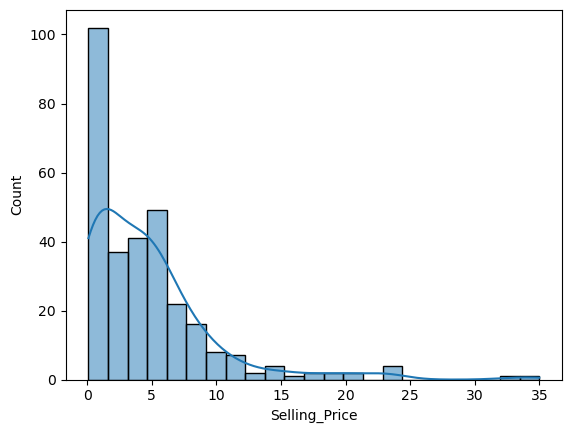

In [10]:
sns.histplot(df['Selling_Price'],kde=True)

### Create a bar chart showing the average selling price for each fuel type (like Petrol, Diesel, CNG).

<Axes: xlabel='Fuel_Type', ylabel='Selling_Price'>

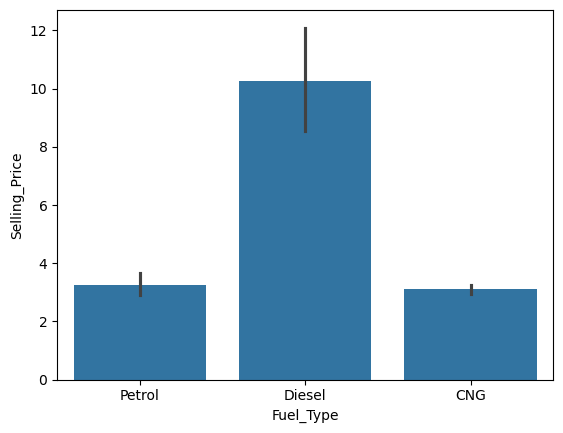

In [11]:
sns.barplot(x=df['Fuel_Type'],y=df['Selling_Price'])

### Make a bar chart showing how many cars there are for each transmission type (Manual or Automatic).

<Axes: xlabel='Transmission', ylabel='count'>

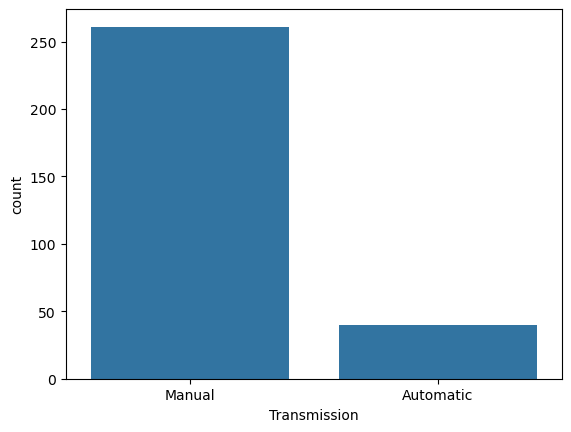

In [13]:
sns.countplot(x=df['Transmission'])

### Create a scatter plot showing the relationship between a car’s present price and its selling price, with different colors for each fuel type.

<Axes: xlabel='Present_Price', ylabel='Selling_Price'>

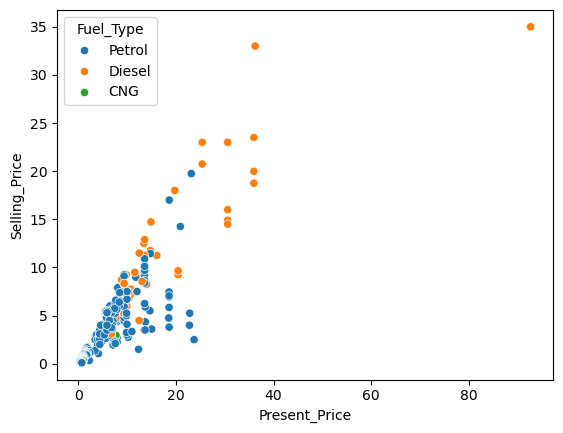

In [15]:
sns.scatterplot(x=df['Present_Price'],y=df['Selling_Price'],hue=df['Fuel_Type'])

### Create a heatmap showing the correlation between all numeric columns in df, with values annotated and colored from negative (cool) to positive (warm) correlations.

<Axes: >

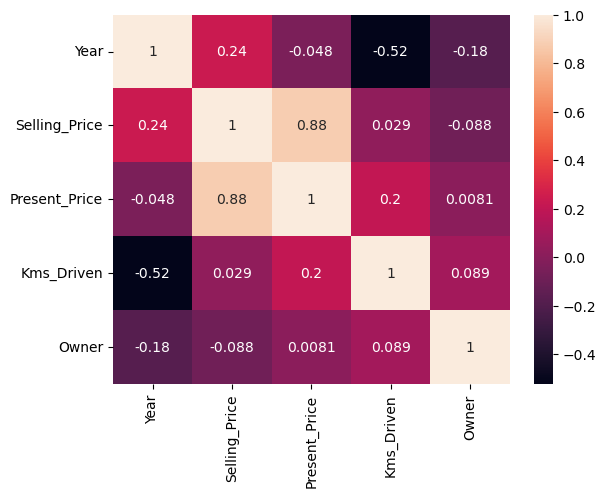

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

### Split X and y features.
X → Independent features (input variables, predictors).                                                                         
y → Dependent feature (target variable, output we want to predict).

In [18]:
df.drop('Owner',inplace=True,axis=1)

In [20]:
X=df.drop('Selling_Price',axis=1)
y=df['Selling_Price']

### We have some object-type columns representing categorical data.
### We will use LabelEncoder(from sklearn.preprocessing) to convert them into numeric labels (0, 1, 2, …) for use in machine learning models.

In [22]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in X.columns:
    if X[col].dtype=='object':
        X[col]=le.fit_transform(X[col])


### We split the data into training and testing sets, with 80% for training and 20% for testing.
### we will import train_test_split from sklearn.model_selection

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

### Now as we have splitted our Independent and Dependent Features.
### Let's import our DecisionTreeRegressor from sklearn.tree and train our X_train and y_train.

In [26]:
from sklearn.tree import DecisionTreeRegressor
model1=DecisionTreeRegressor()
model1.fit(X_train,y_train)

DecisionTreeRegressor()

### Now we have trained our model and now it's time to make some prediction on `unseen data (X_test)`.

In [27]:
y_pred=model1.predict(X_test)

### Now we are at the final step of our project, which is evaluating the model’s accuracy to see how well it is predicting.

In [28]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9456274583531713

In [29]:
train_pred=model1.predict(X_train)
test_pred=model1.predict(X_test)

In [31]:
train_score=r2_score(y_train,train_pred)
test_score=r2_score(y_test,test_pred)
print(train_score)
print(test_score)

1.0
0.9456274583531713


### PARAMETER SEARCH


In [39]:
from sklearn.model_selection import RandomizedSearchCV
model=DecisionTreeRegressor(random_state=42)
params={
    "criterion":['squarred_error','friedman_mse','poisson','absolute_error'],
    'max_depth':np.arange(1,20,1),
    'min_samples_split':np.arange(2,20,1),
    'max_features':[1,'sqrt','log2'],
    'max_leaf_nodes':np.arange(1,20,1)
}
grid=RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    cv=5,
    random_state=42,
    n_iter=100,
    n_jobs=-1
)



In [41]:
params["criterion"] = [
    "squared_error",
    "friedman_mse",
    "poisson",
    "absolute_error"
]
params["max_leaf_nodes"] = np.arange(2, 20)

grid = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_distributions=params,
    cv=5,
    random_state=42,
    n_iter=100,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'min_samples_split': np.int64(3), 'max_leaf_nodes': np.int64(16), 'max_features': 'log2', 'max_depth': np.int64(13), 'criterion': 'absolute_error'}
Best CV score: 0.7983713860420754


In [42]:
best_model=grid.best_estimator_
best_model.fit(X_train,y_train)

y_pred_best=best_model.predict(X_test)
print(r2_score(y_test,y_pred_best))

0.8615098819453818
